
TRAIN:
  anger          : 3334 изображений
  contempt       : 3334 изображений
  disgust        : 3334 изображений
  fear           : 3334 изображений
  happy          : 3334 изображений
  neutral        : 3334 изображений
  sad            : 3334 изображений
  surprise       : 3334 изображений

TEST:
  anger          : 716 изображений
  contempt       : 716 изображений
  disgust        : 716 изображений
  fear           : 716 изображений
  happy          : 716 изображений
  neutral        : 716 изображений
  sad            : 716 изображений
  surprise       : 716 изображений

VALIDATION:
  anger          : 714 изображений
  contempt       : 714 изображений
  disgust        : 714 изображений
  fear           : 714 изображений
  happy          : 714 изображений
  neutral        : 714 изображений
  sad            : 714 изображений
  surprise       : 714 изображений


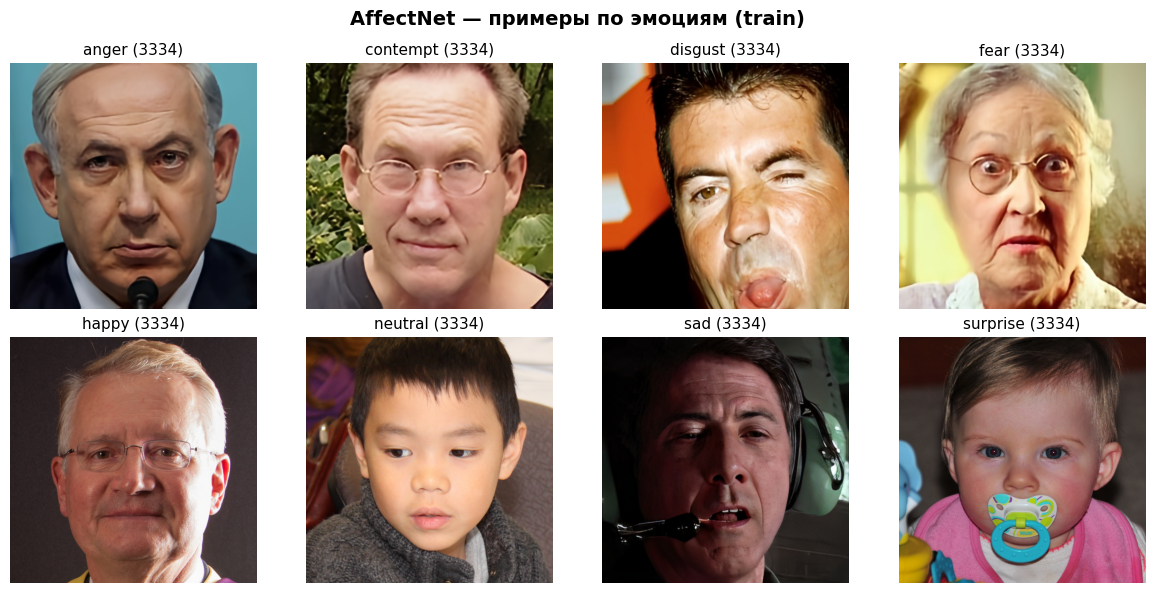


✅ График сохранён: /kaggle/working/affectnet_samples.png


In [1]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

# ========== НАСТРОЙКИ ==========
AFFECTNET_PATH = "/kaggle/input/datasets/shantanupandey1/affectnet-augmented/Affectnet fer"

# Папки: train, test, validation
for split in ["train", "test", "validation"]:
    split_path = os.path.join(AFFECTNET_PATH, split)
    if os.path.isdir(split_path):
        print(f"\n{split.upper()}:")
        for emotion in sorted(os.listdir(split_path)):
            emotion_path = os.path.join(split_path, emotion)
            if os.path.isdir(emotion_path):
                count = len([f for f in os.listdir(emotion_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
                print(f"  {emotion:<15}: {count} изображений")

# ========== ПРИМЕРЫ ИЗ TRAIN ==========
train_path = os.path.join(AFFECTNET_PATH, "train")
if os.path.isdir(train_path):
    emotions = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
    
    n_cols = 4
    n_rows = (len(emotions) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3*n_rows))
    axes = axes.flatten()
    
    for i, emotion in enumerate(emotions):
        emotion_path = os.path.join(train_path, emotion)
        img_files = [f for f in os.listdir(emotion_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if img_files:
            img = Image.open(os.path.join(emotion_path, random.choice(img_files))).convert("RGB")
            axes[i].imshow(img)
            axes[i].set_title(f"{emotion} ({len(img_files)})", fontsize=11)
        axes[i].axis('off')
    
    for j in range(len(emotions), len(axes)):
        axes[j].axis('off')
    
    plt.suptitle("AffectNet — примеры по эмоциям (train)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("/kaggle/working/affectnet_samples.png", dpi=150)
    plt.show()
    print(f"\n✅ График сохранён: /kaggle/working/affectnet_samples.png")

In [3]:
import os
import shutil
from PIL import Image
from tqdm import tqdm

# ========== НАСТРОЙКИ ==========
AFFECTNET_PATH = "/kaggle/input/datasets/shantanupandey1/affectnet-augmented/Affectnet fer"
TRAIN_SOURCE = os.path.join(AFFECTNET_PATH, "train")
OUTPUT_DIR = "/kaggle/working/affectnet_processed/train"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Словарь эмоция → промпт
EMOTION_PROMPTS = {
    "anger":    "a person looking very angry, furious expression",
    "contempt": "a person with a contempt expression, scornful look",
    "disgust":  "a person looking disgusted, grossed out expression",
    "fear":     "a person with a scared expression, terrified look",
    "happy":    "a person smiling happily, joyful expression",
    "neutral":  "a person with a neutral expression, calm face",
    "sad":      "a person looking sad and thoughtful, sorrowful expression",
    "surprise": "a person with a surprised expression, shocked look",
}

# ========== ОБРАБОТКА ==========
metadata_lines = []
total = 0

for emotion, prompt in EMOTION_PROMPTS.items():
    emotion_path = os.path.join(TRAIN_SOURCE, emotion)
    if not os.path.isdir(emotion_path):
        continue
    
    img_files = [f for f in os.listdir(emotion_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for img_file in tqdm(img_files[:100], desc=f"{emotion}"):
        src = os.path.join(emotion_path, img_file)
        dst_name = f"{emotion}_{img_file}"
        dst = os.path.join(OUTPUT_DIR, dst_name)
        
        try:
            img = Image.open(src).convert("RGB").resize((512, 512), Image.LANCZOS)
            img.save(dst)
            metadata_lines.append(f"{dst_name},{prompt}")
            total += 1
        except Exception as e:
            print(f"  [ERROR] {img_file}: {e}")

# Сохраняем metadata.csv
metadata_path = "/kaggle/working/affectnet_processed/metadata.csv"
with open(metadata_path, "w", encoding="utf-8") as f:
    f.write("file_name,text\n")
    f.write("\n".join(metadata_lines))

print(f"\n✅ Готово: {total} изображений в {OUTPUT_DIR}")
print(f"✅ Metadata: {metadata_path}")

surprise: 100%|██████████| 100/100 [00:06<00:00, 15.78it/s]


✅ Готово: 800 изображений в /kaggle/working/affectnet_processed/train
✅ Metadata: /kaggle/working/affectnet_processed/metadata.csv


In [5]:
# !zip -r affectnet_processed.zip affectnet_processed/

Найден чекпоинт: эпоха 10
Датасет: 800 изображений
Загрузка SD1.5...


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--Realistic_Vision_V4.0_noVAE/snapshots/1685907c0283c7278ba26c5fe561506f564b48d3/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Загрузка чекпоинта: /kaggle/working/lora_affectnet_checkpoints/epoch_10
trainable params: 1,594,368 || all params: 861,115,332 || trainable%: 0.1852

Дообучение: 10 эпох (с 11 по 20)
Learning rate: 0.0001
  Epoch 11, batch 0/800: loss = 0.009567
Epoch 11: avg_loss = 0.144035
  💾 /kaggle/working/lora_affectnet_checkpoints/epoch_11
  Epoch 12, batch 0/800: loss = 0.006412
Epoch 12: avg_loss = 0.153610
  💾 /kaggle/working/lora_affectnet_checkpoints/epoch_12
  Epoch 13, batch 0/800: loss = 0.025514
Epoch 14: avg_loss = 0.137645
  💾 /kaggle/working/lora_affectnet_checkpoints/epoch_14
  Epoch 15, batch 0/800: loss = 0.081312
Epoch 15: avg_loss = 0.152478
  💾 /kaggle/working/lora_affectnet_checkpoints/epoch_15
  Epoch 16, batch 0/800: loss = 0.011999
Epoch 16: avg_loss = 0.138709
  💾 /kaggle/working/lora_affectnet_checkpoints/epoch_16
  Epoch 17, batch 0/800: loss = 0.126303
Epoch 17: avg_loss = 0.133328
  💾 /kaggle/working/lora_affectnet_checkpoints/epoch_17
  Epoch 18, batch 0/800: loss = 0

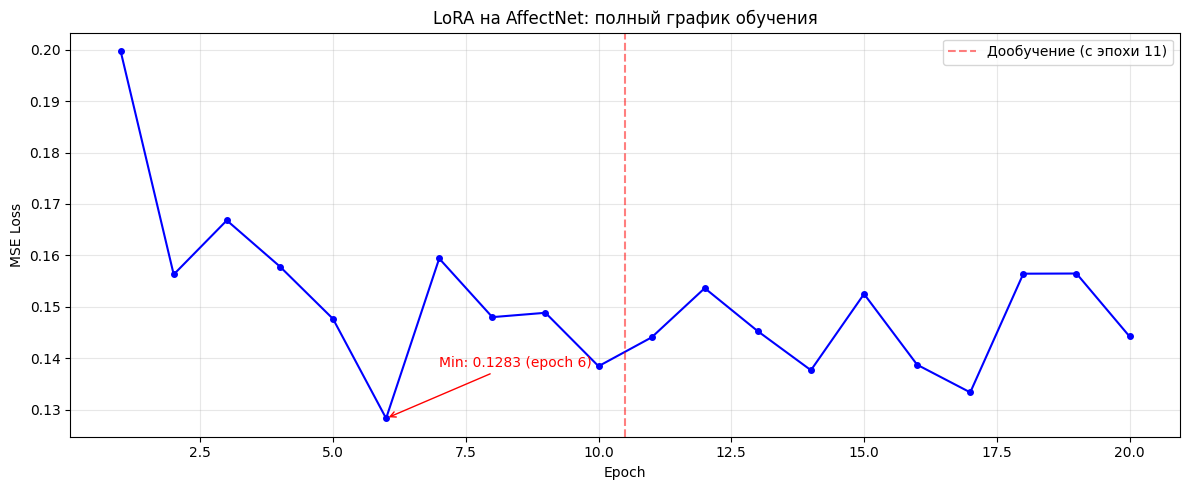

✅ График: /kaggle/working/lora_affectnet_final/loss_plot.png
✅ Итоговые лоссы (20 эпох):
[0.199767, 0.156272, 0.166796, 0.15781872403400485, 0.14763702223543076, 0.12827795611345208, 0.1593816618344863, 0.1479721160628833, 0.1488176963251317, 0.1384257773551508, 0.1440349655857426, 0.15361049761559115, 0.14523025447881083, 0.13764457780402153, 0.15247845214296832, 0.1387086708730203, 0.1333278432203224, 0.15642582992848475, 0.1564585076828371, 0.1442113509972114]


In [15]:
import torch
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from diffusers import StableDiffusionPipeline
from peft import PeftModel
import torch.nn.functional as F
from torch.optim import AdamW
import matplotlib.pyplot as plt

# ========== НАСТРОЙКИ ==========
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32

TRAIN_DIR = "/kaggle/working/affectnet_processed/train"
METADATA_FILE = "/kaggle/working/affectnet_processed/metadata.csv"

# Последний чекпоинт
CHECKPOINT_SOURCE = "/kaggle/working/lora_affectnet_checkpoints/epoch_10"  # папка с чекпоинтами

# Куда сохранять
CHECKPOINT_DIR = "/kaggle/working/lora_affectnet_checkpoints"
FINAL_DIR = "/kaggle/working/lora_affectnet_final"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FINAL_DIR, exist_ok=True)

# # Определяем, с какой эпохи продолжаем
# existing_checkpoints = sorted([
#     int(d.replace("epoch_", "")) 
#     for d in os.listdir(CHECKPOINT_SOURCE) 
#     if d.startswith("epoch_") and os.path.isdir(os.path.join(CHECKPOINT_SOURCE, d))
# ])
# if existing_checkpoints:
LAST_EPOCH = 10#max(existing_checkpoints)
LOAD_CHECKPOINT = CHECKPOINT_SOURCE#os.path.join(CHECKPOINT_SOURCE, f"epoch_{LAST_EPOCH:02d}")
print(f"Найден чекпоинт: эпоха {LAST_EPOCH}")
# else:
#     LAST_EPOCH = 0
#     LOAD_CHECKPOINT = None
#     print("Чекпоинты не найдены, обучение с нуля")

ADDITIONAL_EPOCHS = 20 -   LAST_EPOCH     # добавим 5 эпох
BATCH_SIZE = 1
LEARNING_RATE = 1e-4        
RANK = 8

# Твои старые лоссы (если есть)
old_losses = [0.199767, 0.156272, 0.166796, 0.15781872403400485, 0.14763702223543076, 0.12827795611345208, 0.1593816618344863, 0.1479721160628833, 0.1488176963251317, 0.1384257773551508]

# ========== ДАТАСЕТ ==========
class EmotionDataset(Dataset):
    def __init__(self, metadata_file, train_dir):
        self.train_dir = train_dir
        with open(metadata_file, "r") as f:
            lines = f.read().strip().split("\n")[1:]
        self.data = [line.split(",", 1) for line in lines if line.strip()]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        file_name, prompt = self.data[idx]
        img = Image.open(os.path.join(self.train_dir, file_name)).convert("RGB")
        img = torch.tensor(np.array(img)).permute(2, 0, 1).float() / 127.5 - 1.0
        return {"pixel_values": img, "prompt": prompt}

dataset = EmotionDataset(METADATA_FILE, TRAIN_DIR)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Датасет: {len(dataset)} изображений")

# ========== ЗАГРУЗКА МОДЕЛИ ==========
print("Загрузка SD1.5...")
pipe = StableDiffusionPipeline.from_pretrained(
    "SG161222/Realistic_Vision_V4.0_noVAE",
    torch_dtype=DTYPE,
    use_safetensors=True,
)
pipe = pipe.to(DEVICE)

if LOAD_CHECKPOINT:
    print(f"Загрузка чекпоинта: {LOAD_CHECKPOINT}")
    pipe.unet = PeftModel.from_pretrained(pipe.unet, LOAD_CHECKPOINT)
    pipe.unet.set_adapter("default")
else:
    print("Обучение с нуля (без чекпоинта)")
    for param in pipe.unet.parameters():
        param.requires_grad = False
    from peft import LoraConfig, get_peft_model
    lora_config = LoraConfig(
        r=RANK, lora_alpha=RANK*2,
        target_modules=["to_q", "to_k", "to_v", "to_out.0"],
        lora_dropout=0.0, bias="none",
    )
    pipe.unet = get_peft_model(pipe.unet, lora_config)

unet = pipe.unet
unet.train()
unet.print_trainable_parameters()

optimizer = AdamW(unet.parameters(), lr=LEARNING_RATE)
noise_scheduler = pipe.scheduler

# Кодируем текст
text_encoder = pipe.text_encoder
tokenizer = pipe.tokenizer

prompts = [item[1] for item in dataset.data]
encoded_prompts = []
for prompt in prompts:
    tokens = tokenizer(
        prompt, padding="max_length", max_length=77, truncation=True, return_tensors="pt"
    ).input_ids.to(DEVICE)
    with torch.no_grad():
        emb = text_encoder(tokens).last_hidden_state
    encoded_prompts.append(emb)

# ========== ПРОДОЛЖЕНИЕ ОБУЧЕНИЯ ==========
print(f"\nДообучение: {ADDITIONAL_EPOCHS} эпох (с {LAST_EPOCH+1} по {LAST_EPOCH+ADDITIONAL_EPOCHS})")
print(f"Learning rate: {LEARNING_RATE}")

epoch_losses = old_losses.copy()
batch_losses = []

for epoch in range(ADDITIONAL_EPOCHS):
    total_loss = 0
    current_epoch = LAST_EPOCH + epoch + 1

    for batch_idx, batch in enumerate(dataloader):
        optimizer.zero_grad()

        img = batch["pixel_values"].to(DEVICE, dtype=DTYPE)
        prompt_emb = encoded_prompts[batch_idx]

        with torch.no_grad():
            latents = pipe.vae.encode(img).latent_dist.sample() * pipe.vae.config.scaling_factor

        noise = torch.randn_like(latents)
        timestep = torch.randint(0, noise_scheduler.config.num_train_timesteps, (1,), device=DEVICE)
        noisy_latents = noise_scheduler.add_noise(latents, noise, timestep)

        noise_pred = unet(noisy_latents, timestep, encoder_hidden_states=prompt_emb).sample
        loss = F.mse_loss(noise_pred, noise)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        batch_losses.append(loss.item())

        if batch_idx % 5000 == 0:
            print(f"  Epoch {current_epoch}, batch {batch_idx}/{len(dataloader)}: loss = {loss.item():.6f}")

    avg_loss = total_loss / len(dataloader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {current_epoch}: avg_loss = {avg_loss:.6f}")

    # Чекпоинт
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"epoch_{current_epoch:02d}")
    unet.save_pretrained(checkpoint_path)
    print(f"  💾 {checkpoint_path}")

# ========== ФИНАЛ ==========
unet.save_pretrained(FINAL_DIR)
print(f"\n✅ Финальная модель: {FINAL_DIR}")

# ========== ГРАФИК ==========
fig, ax = plt.subplots(figsize=(12, 5))
all_epochs = range(1, len(epoch_losses) + 1)
ax.plot(all_epochs, epoch_losses, 'b-o', markersize=4, linewidth=1.5)
if LAST_EPOCH > 0:
    ax.axvline(x=LAST_EPOCH + 0.5, color='red', linestyle='--', alpha=0.5, label=f'Дообучение (с эпохи {LAST_EPOCH+1})')
    ax.legend()
min_idx = np.argmin(epoch_losses)
ax.annotate(f'Min: {epoch_losses[min_idx]:.4f} (epoch {min_idx+1})',
            xy=(min_idx+1, epoch_losses[min_idx]),
            xytext=(min_idx+2, epoch_losses[min_idx] + 0.01),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("LoRA на AffectNet: полный график обучения")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, "loss_plot.png"), dpi=150)
plt.show()

print(f"✅ График: {os.path.join(FINAL_DIR, 'loss_plot.png')}")
print(f"✅ Итоговые лоссы ({len(epoch_losses)} эпох):")
print(epoch_losses)

In [11]:
!ls /kaggle/input/datasets/kolyagudkov/afnet3

adapter_config.json  adapter_model.safetensors


In [14]:
0.199767, 0.156272, 0.166796

(0.199767, 0.156272, 0.166796)

In [ ]:
# Просто печатаем что-то каждые 30 секунд
import time

while True:
    print(".", end="", flush=True)
    time.sleep(30)

In [ ]:
# !zip -r affectnet_processed.zip affectnet_processed/

In [2]:
!ls /kaggle/working

In [ ]:
1